In [1]:
!pip install -U ultralytics wandb

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 10.3 MB/s  0:00:00
   ---------------------------------------- 0.0/24.9 MB ? eta -:--:--
   --- ------------------------------------ 2.4/24.9 MB 11.2 MB/s eta 0:00:03
   ------- -------------------------------- 4.7/24.9 MB 11.4 MB/s eta 0:00:02
   ----------- ---------------------------- 7.1/24.9 MB 11.5 MB/s eta 0:00:02
   --------------- ------------------------ 9.7/24.9 MB 11.6 MB/s eta 0:00:02
   ------------------- -------------------- 12.1/24.9 MB 11.8 MB/s eta 0:00:02
   ----------------------- ---------------- 14.7/24.9 MB 11.8 MB/s eta 0:00:01
   --------------------------- ------------ 17.0/24.9 MB 11.8 MB/s eta 0:00:01
   ------------------------------- -------- 19.4/24.9 MB 11.8 MB/s eta 0:00:01
   ---------------------------------- ----- 21.8/24.9 MB 11.8 MB/s eta 0:00:01
   -------------------------------------- - 24.1/24.9 MB 11.7 MB/s eta 0:00:01
 

In [1]:
def print_excel_row(model_name, val, test):
    print(f"{model_name}\t"
          f"{val.box.mr:.4f}\t"
          f"{val.box.mp:.4f}\t"
          f"{val.box.map50:.4f}\t"
          f"{val.box.map:.4f}\t"
          f"{test.box.mr:.4f}\t"
          f"{test.box.mp:.4f}\t"
          f"{test.box.map50:.4f}\t"
          f"{test.box.map:.4f}")

In [6]:
yaml_content = """
path: dataset

train: yolo_dataset/images/train
val: yolo_dataset/images/val
test: yolo_dataset/images/test

nc: 3
names: ['WBC', 'RBC', 'Platelets']
"""

with open("wbc.yaml", "w") as f:
    f.write(yaml_content)

LR Tuning

In [9]:
from ultralytics import YOLO

models = {
    "LR_0.001": "runs/detect/11s_baseline/weights/best.pt",
    "LR_0.0005": "runs/detect/11s_lr_0.0005/weights/best.pt",
    "LR_0.0001": "runs/detect/11s_lr_0.0001/weights/best.pt",
    "LR_0.00001": "runs/detect/11s_lr_0.00001/weights/best.pt"
}

results = []

for name, path in models.items():
    model = YOLO(path)

    metrics = model.val(data="wbc.yaml", split="val", verbose=False)

    results.append({
        "Model": name,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map
    })

print("Model\tPrecision\tRecall\tmAP50\tmAP50-95")
for r in results:
    print(f"{r['Model']}\t{r['Precision']:.4f}\t{r['Recall']:.4f}\t{r['mAP50']:.4f}\t{r['mAP50-95']:.4f}")

Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 443.8123.7 MB/s, size: 20.4 KB)
val: Scanning D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\labels\val.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.3s0.6ss
                   all         72       1006      0.882      0.889      0.929      0.616
Speed: 2.1ms preprocess, 13.2ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\runs\detect\val11
Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOL

Base LR with Augmentation

In [11]:
from ultralytics import YOLO

models = {
    "Base LR - No Augment"  : "runs/detect/11s_baseline/weights/best.pt",
    "Base LR - Recommended" : "runs/detect/11s_baseline_augment/weights/best.pt",
    "Base LR - Strong"      : "runs/detect/11s_baseline_aug_strong/weights/best.pt",
}

results = []

for name, path in models.items():
    model = YOLO(path)

    metrics = model.val(data="wbc.yaml", split="val", verbose=False)

    results.append({
        "Model": name,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map
    })

print("Model\tPrecision\tRecall\tmAP50\tmAP50-95")
for r in results:
    print(f"{r['Model']}\t{r['Precision']:.4f}\t{r['Recall']:.4f}\t{r['mAP50']:.4f}\t{r['mAP50-95']:.4f}")

Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 315.982.8 MB/s, size: 20.2 KB)
val: Scanning D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\labels\val.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.3s0.5s8s
                   all         72       1006      0.882      0.889      0.929      0.616
Speed: 2.3ms preprocess, 11.6ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\runs\detect\val
Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO1

Best LR with Augment

In [12]:
from ultralytics import YOLO

models = {
    "Best LR - No Augment"  : "runs/detect/11s_lr_0.00001/weights/best.pt",
    "Best LR - Recommended" : "runs/detect/11s_lr_augment/weights/best.pt",
    "Best LR - Strong"      : "runs/detect/11s_lr_strong_augment/weights/best.pt",
}

results = []

for name, path in models.items():
    model = YOLO(path)

    metrics = model.val(data="wbc.yaml", split="val", verbose=False)

    results.append({
        "Model": name,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map
    })

print("Model\tPrecision\tRecall\tmAP50\tmAP50-95")
for r in results:
    print(f"{r['Model']}\t{r['Precision']:.4f}\t{r['Recall']:.4f}\t{r['mAP50']:.4f}\t{r['mAP50-95']:.4f}")

Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 336.9151.0 MB/s, size: 19.6 KB)
val: Scanning D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\labels\val.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.2s0.5ss
                   all         72       1006      0.863      0.907      0.922      0.634
Speed: 2.1ms preprocess, 11.5ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\runs\detect\val4
Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO

Auto Tuning vs Manual Tuning (Fair harus ke Test)

In [23]:
from ultralytics import YOLO

models = {
    "Best LR - Recommended" : "runs/detect/11s_lr_augment/weights/best.pt",
    "Auto Tuning"           : "runs/detect/11s_auto_tune/weights/best.pt",
}

results = []

for name, path in models.items():
    model = YOLO(path)

    metrics = model.val(data="wbc.yaml", split="test", verbose=False)

    results.append({
        "Model": name,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map
    })

print("Model\tPrecision\tRecall\tmAP50\tmAP50-95")
for r in results:
    print(f"{r['Model']}\t{r['Precision']:.4f}\t{r['Recall']:.4f}\t{r['mAP50']:.4f}\t{r['mAP50-95']:.4f}")

Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 458.7134.8 MB/s, size: 20.2 KB)
val: Scanning D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\labels\test.cache... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2s/it 3.6s1.2ss
                   all         36        485      0.868      0.898      0.939       0.67
Speed: 2.4ms preprocess, 12.2ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\runs\detect\val12
Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YO

YOLOv8s vs YOLOv11s (Tuned with same Parameter) - Test Set

In [15]:
from ultralytics import YOLO

models = {
    "YOLOv8s Best LR - Recommended" : "runs/detect/v8s_tuned_comparison/weights/best.pt",
    "YOLO11s Best LR - Recommended" : "runs/detect/11s_lr_augment/weights/best.pt",
}

results = []

for name, path in models.items():
    model = YOLO(path)

    metrics = model.val(data="wbc.yaml", split="test", verbose=False)

    results.append({
        "Model": name,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map
    })

print("Model\tPrecision\tRecall\tmAP50\tmAP50-95")
for r in results:
    print(f"{r['Model']}\t{r['Precision']:.4f}\t{r['Recall']:.4f}\t{r['mAP50']:.4f}\t{r['mAP50-95']:.4f}")

Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 171.681.9 MB/s, size: 21.1 KB)
val: Scanning D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\labels\test.cache... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5s/it 4.4s1.9s0s
                   all         36        485      0.801      0.919      0.909      0.637
Speed: 3.3ms preprocess, 19.7ms inference, 0.0ms loss, 9.8ms postprocess per image
Results saved to D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\runs\detect\val8
Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO1

In [35]:
import time
import os

model_v8 = YOLO("runs/detect/v8s_tuned_comparison/weights/best.pt")

start = time.time()
results = model_v8.predict("dataset/yolo_dataset/images/test", stream=True)

for r in results:
    pass
end = time.time()

fps = len(os.listdir("dataset/yolo_dataset/images/test")) / (end - start)
print("FPS:", fps)


image 1/36 d:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\images\test\BloodImage_00003.jpg: 480x640 1 WBC, 21 RBCs, 2 Plateletss, 28.6ms
image 2/36 d:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\images\test\BloodImage_00005.jpg: 480x640 1 WBC, 19 RBCs, 3 Plateletss, 9.4ms
image 3/36 d:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\images\test\BloodImage_00007.jpg: 480x640 1 WBC, 21 RBCs, 1 Platelets, 10.7ms
image 4/36 d:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\images\test\BloodImage_00009.jpg: 480x640 1 WBC, 23 RBCs, 1 Platelets, 9.8ms
image 5/36 d:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\images\test\BloodImage_00022.jpg: 480x640 1 WBC, 24 RBCs, 3 Plateletss, 10.0ms
image 6/36 d:\Backup Data\BINUS\S2\Sem

In [36]:
import time
import os

model_v11 = YOLO("runs/detect/11s_lr_augment/weights/best.pt")

start = time.time()
results = model_v11.predict("dataset/yolo_dataset/images/test", stream=True)

for r in results:
    pass
end = time.time()

fps = len(os.listdir("dataset/yolo_dataset/images/test")) / (end - start)
print("FPS:", fps)


image 1/36 d:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\images\test\BloodImage_00003.jpg: 480x640 1 WBC, 23 RBCs, 1 Platelets, 14.0ms
image 2/36 d:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\images\test\BloodImage_00005.jpg: 480x640 1 WBC, 22 RBCs, 3 Plateletss, 11.2ms
image 3/36 d:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\images\test\BloodImage_00007.jpg: 480x640 1 WBC, 15 RBCs, 10.5ms
image 4/36 d:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\images\test\BloodImage_00009.jpg: 480x640 1 WBC, 26 RBCs, 1 Platelets, 9.5ms
image 5/36 d:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\images\test\BloodImage_00022.jpg: 480x640 1 WBC, 21 RBCs, 3 Plateletss, 10.0ms
image 6/36 d:\Backup Data\BINUS\S2\Semester 2 Perio

Per Class

Best LR - No Augment (Base)

In [19]:
model =  YOLO("runs/detect/11s_lr_0.00001//weights/best.pt")

val_metrics = model.val(data="wbc.yaml", split="val")
test_metrics = model.val(data="wbc.yaml", split="test")

print("Model\tVal Recall\tVal Precision\tVal mAP50\tVal mAP50-95\tTest Recall\tTest Precision\tTest mAP50\tTest mAP50-95")
print_excel_row("YOLO11s_Base", val_metrics, test_metrics)

Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 284.7179.3 MB/s, size: 19.5 KB)
val: Scanning D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\labels\val.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.3s0.6ss
                   all         72       1006      0.863      0.907      0.922      0.634
                   WBC         69         71      0.952          1      0.992      0.826
                   RBC         70        844      0.806      0.849      0.883      0.619
             Platelets         47         91      0.832      0.871      0.892      0.458
Speed: 2.3ms preprocess, 11.9ms inference

Best LR - Recommended Augment

In [20]:
model =  YOLO("runs/detect/11s_lr_augment/weights/best.pt")

val_metrics = model.val(data="wbc.yaml", split="val")
test_metrics = model.val(data="wbc.yaml", split="test")

print("Model\tVal Recall\tVal Precision\tVal mAP50\tVal mAP50-95\tTest Recall\tTest Precision\tTest mAP50\tTest mAP50-95")
print_excel_row("YOLO11s_Best_Recommended", val_metrics, test_metrics)

Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 305.397.1 MB/s, size: 19.6 KB)
val: Scanning D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\labels\val.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.1it/s 4.7s0.6s3s
                   all         72       1006      0.885      0.913      0.933      0.632
                   WBC         69         71      0.945          1       0.98      0.812
                   RBC         70        844      0.826      0.827      0.887      0.623
             Platelets         47         91      0.885      0.912      0.932       0.46
Speed: 2.6ms preprocess, 13.4ms inference

Best LR - Strong Augment

In [21]:
model =  YOLO("runs/detect/11s_lr_strong_augment//weights/best.pt")

val_metrics = model.val(data="wbc.yaml", split="val")
test_metrics = model.val(data="wbc.yaml", split="test")

print("Model\tVal Recall\tVal Precision\tVal mAP50\tVal mAP50-95\tTest Recall\tTest Precision\tTest mAP50\tTest mAP50-95")
print_excel_row("YOLO11s_Best_Strong", val_metrics, test_metrics)

Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 406.0119.6 MB/s, size: 20.3 KB)
val: Scanning D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\labels\val.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.2s0.5ss
                   all         72       1006      0.851      0.917      0.913      0.618
                   WBC         69         71      0.931          1      0.971      0.798
                   RBC         70        844      0.772      0.875      0.882      0.617
             Platelets         47         91      0.851      0.875      0.886      0.438
Speed: 1.9ms preprocess, 12.5ms inference

Visualize

Load Model

In [29]:
from ultralytics import YOLO

best_model = YOLO("runs/detect/11s_lr_augment/weights/best.pt")

In [7]:
val_metrics = best_model.val(data="wbc.yaml", split="val")
test_metrics = best_model.val(data="wbc.yaml", split="test")

print("Model\tVal Recall\tVal Precision\tVal mAP50\tVal mAP50-95\tTest Recall\tTest Precision\tTest mAP50\tTest mAP50-95")
print_excel_row("Best Model", val_metrics, test_metrics)

Ultralytics 8.4.38  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 357.1118.9 MB/s, size: 19.4 KB)
val: Scanning D:\Backup Data\BINUS\S2\Semester 2 Periode 1\Deep Learning\AoL 1\Experiment\Final\dataset\yolo_dataset\labels\val.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4s/it 7.2s1.0s8
                   all         72       1006      0.885      0.913      0.933      0.632
                   WBC         69         71      0.945          1       0.98      0.812
                   RBC         70        844      0.826      0.827      0.887      0.623
             Platelets         47         91      0.885      0.912      0.932       0.46
Speed: 4.0ms preprocess, 16.4ms inference

In [30]:
import os, cv2
import matplotlib.pyplot as plt

class_names = ['WBC', 'RBC', 'Platelets']

def visualize_gt_vs_pred(image_path, model):
    img = cv2.imread(image_path)
    if img is None:
        print("Image failed to load:", image_path)
    h, w, _ = img.shape

    label_path = image_path.replace("images", "labels").replace(".jpg", ".txt")

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                label = class_names[int(cls)]

                cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
                cv2.putText(
                    img,
                    f"GT: {label}",
                    (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0,255,0),
                    2
                )

    results = model(img)[0]

    boxes = results.boxes.xyxy
    scores = results.boxes.conf
    classes = results.boxes.cls

    for box, score, cls in zip(boxes, scores, classes):
        x1, y1, x2, y2 = map(int, box)
        label = class_names[int(cls)]

        cv2.rectangle(img, (x1, y1), (x2, y2), (0,0,255), 2)
        cv2.putText(
            img,
            f"{label} {score:.2f}",
            (x1, y2 + 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,0,255),
            2
        )

    plt.figure(figsize=(8,8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
    plt.close()


0: 480x640 1 WBC, 20 RBCs, 21.4ms
Speed: 18.1ms preprocess, 21.4ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


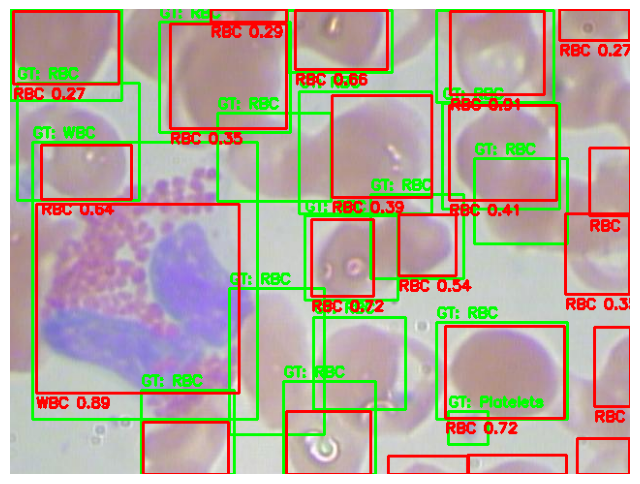

dataset/yolo_dataset/images/test\BloodImage_00009.jpg

0: 480x640 1 WBC, 21 RBCs, 1 Platelets, 14.1ms
Speed: 2.5ms preprocess, 14.1ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


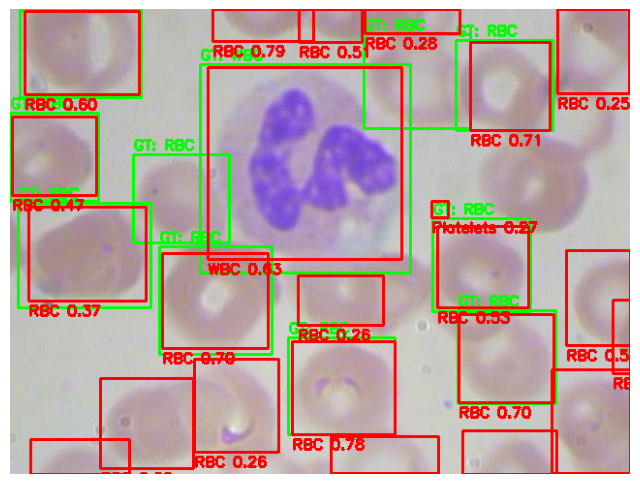

dataset/yolo_dataset/images/test\BloodImage_00230.jpg

0: 480x640 1 WBC, 11 RBCs, 14.0ms
Speed: 1.2ms preprocess, 14.0ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


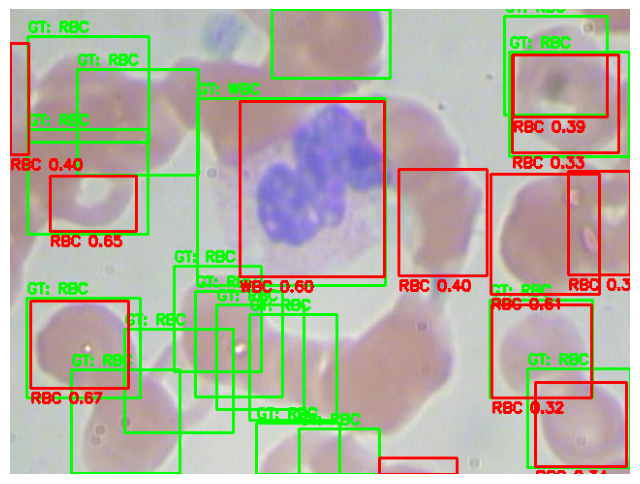

dataset/yolo_dataset/images/test\BloodImage_00007.jpg

0: 480x640 1 WBC, 16 RBCs, 2 Plateletss, 23.8ms
Speed: 3.1ms preprocess, 23.8ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)


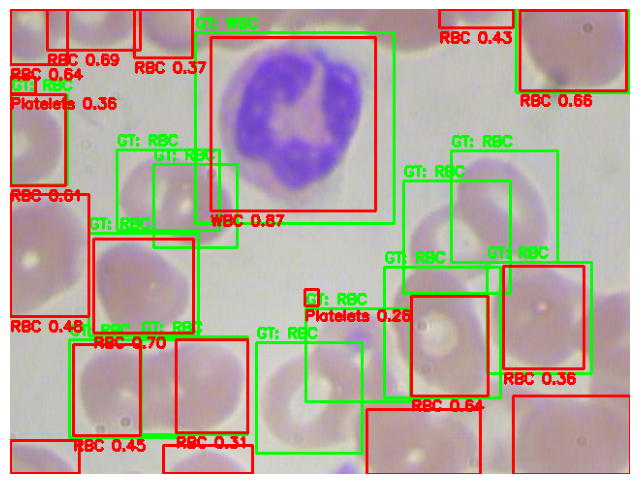

dataset/yolo_dataset/images/test\BloodImage_00161.jpg

0: 480x640 3 WBCs, 19 RBCs, 15.5ms
Speed: 2.3ms preprocess, 15.5ms inference, 4.2ms postprocess per image at shape (1, 3, 480, 640)


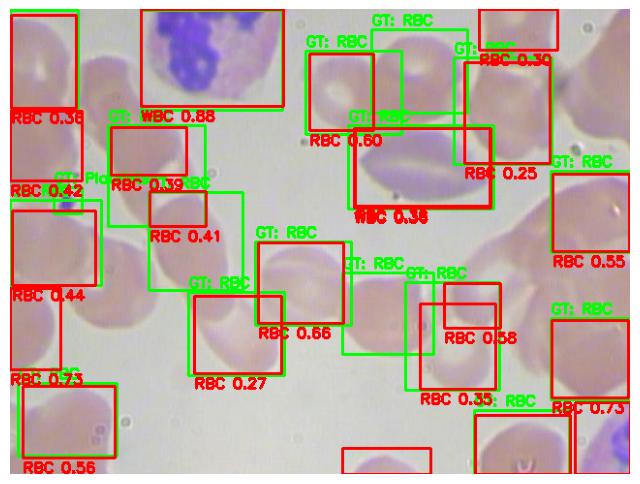

dataset/yolo_dataset/images/test\BloodImage_00103.jpg


In [31]:
import os
import random

def process_random_predictions(dataset_path, model, num_samples=5):

    all_files = [f for f in os.listdir(dataset_path) if f.lower().endswith(('.jpg'))]
    
    sample_size = min(num_samples, len(all_files))
    selected_files = random.sample(all_files, sample_size)
    
    for filename in selected_files:
        image_path = os.path.join(dataset_path, filename)
        
        try:
            visualize_gt_vs_pred(image_path, model)
            print(image_path)
        except Exception as e:
            print(f"Error processing {filename}: {e}")

dataset_path = "dataset/yolo_dataset/images/test"
process_random_predictions(dataset_path, best_model)


0: 480x640 2 WBCs, 17 RBCs, 3 Plateletss, 19.0ms
Speed: 3.7ms preprocess, 19.0ms inference, 2.9ms postprocess per image at shape (1, 3, 480, 640)


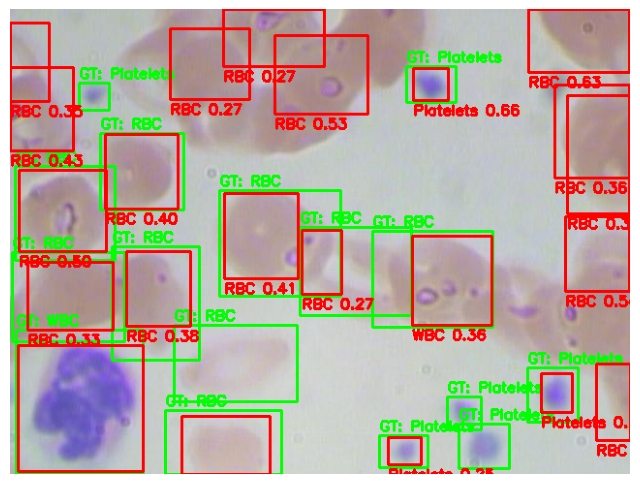

In [39]:
visualize_gt_vs_pred(
    "dataset/yolo_dataset/images/test\BloodImage_00156.jpg",
    best_model
)

Robustness Trial

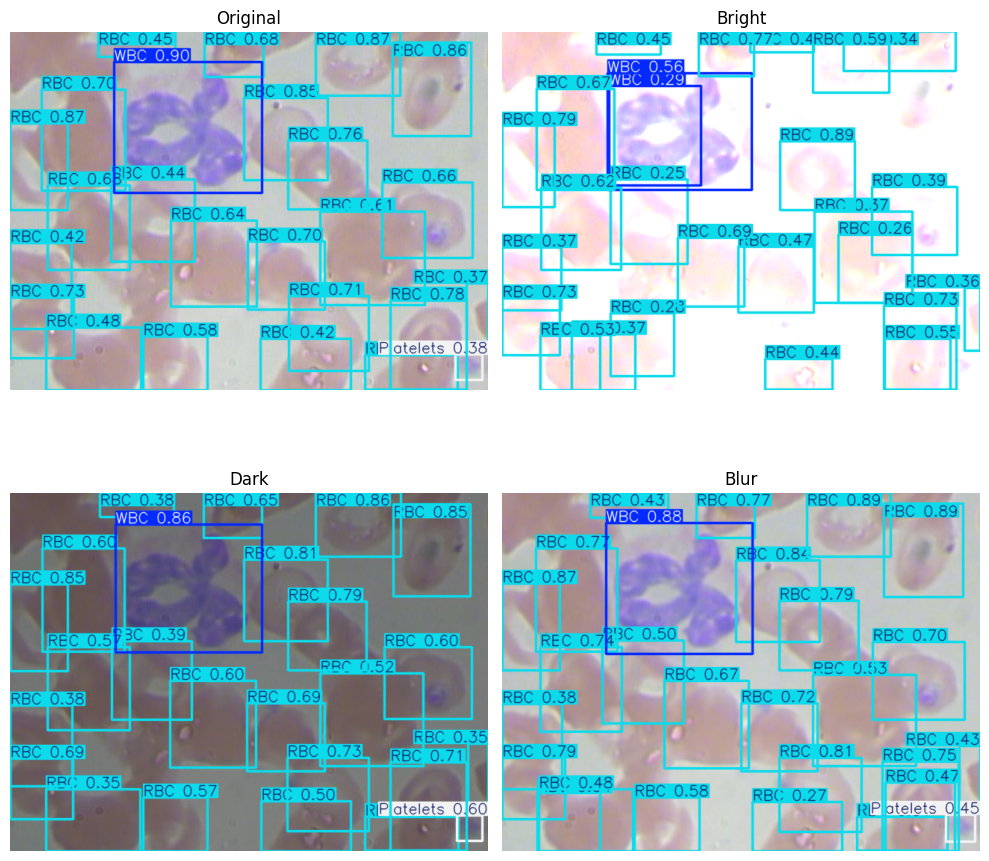

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img_path = "dataset/yolo_dataset/images/test/BloodImage_00003.jpg" 
img = cv2.imread(img_path)

def change_brightness(img, factor):
    return cv2.convertScaleAbs(img, alpha=factor, beta=0)

def add_blur(img):
    return cv2.GaussianBlur(img, (5,5), 0)

variants = {
    "Original": img,
    "Bright": change_brightness(img, 1.5),
    "Dark": change_brightness(img, 0.6),
    "Blur": add_blur(img),
}

plt.figure(figsize=(10,10))

for i, (title, var_img) in enumerate(variants.items()):
    results = best_model.predict(var_img, verbose=False)
    plotted = results[0].plot()

    plt.subplot(2, 2, i+1)
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.savefig("robustness_grid.jpg", dpi=300)
plt.show()

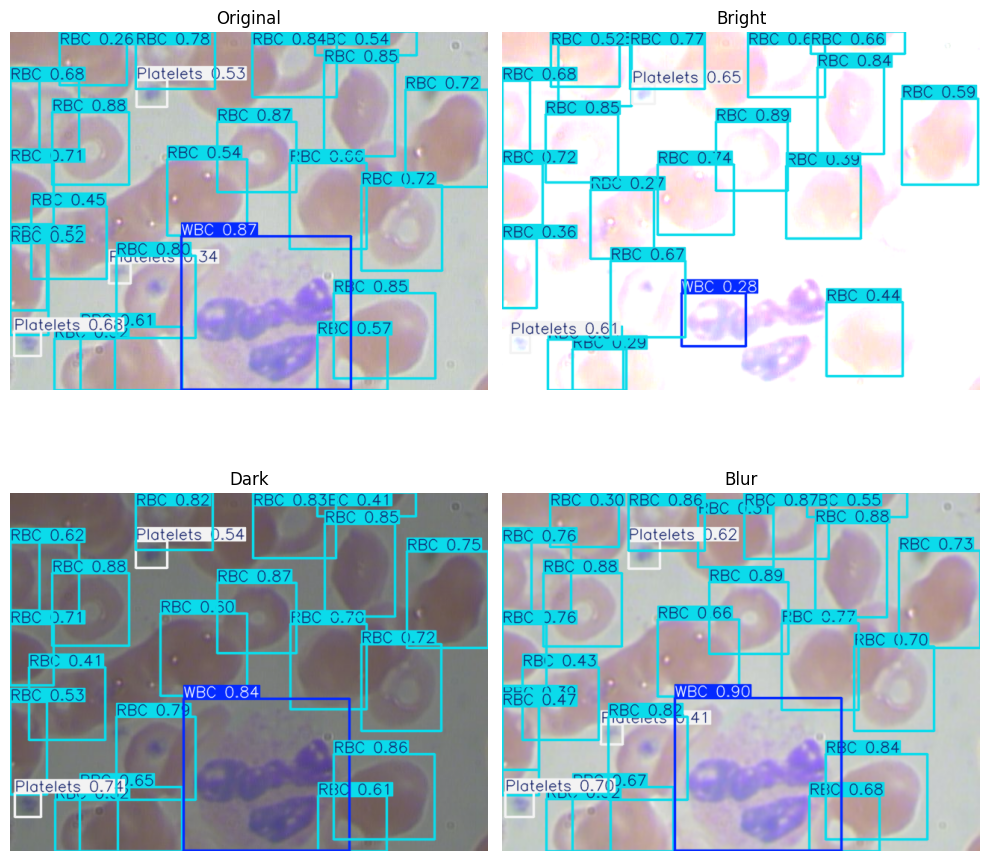

In [19]:
import cv2
import matplotlib.pyplot as plt


img_path = "dataset/yolo_dataset/images/test/BloodImage_00005.jpg" 
img = cv2.imread(img_path)

def change_brightness(img, factor):
    return cv2.convertScaleAbs(img, alpha=factor, beta=0)

def add_blur(img):
    return cv2.GaussianBlur(img, (5,5), 0)

variants = {
    "Original": img,
    "Bright": change_brightness(img, 1.5),
    "Dark": change_brightness(img, 0.6),
    "Blur": add_blur(img),
}

plt.figure(figsize=(10,10))

for i, (title, var_img) in enumerate(variants.items()):
    results = best_model.predict(var_img, verbose=False)
    plotted = results[0].plot()

    plt.subplot(2, 2, i+1)
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.savefig("robustness_grid.jpg", dpi=300)
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt

class_names = ['WBC', 'RBC', 'Platelets']

colors = {
    'WBC': (255, 0, 0),        # Blue
    'RBC': (0, 255, 0),        # Green
    'Platelets': (0, 0, 255)   # Red
}

def visualize_inference(image_path, model, conf_threshold=0.25):
    img = cv2.imread(image_path)

    results = model(img)[0]

    boxes = results.boxes.xyxy
    scores = results.boxes.conf
    classes = results.boxes.cls

    for box, score, cls in zip(boxes, scores, classes):
        if score < conf_threshold:
            continue

        x1, y1, x2, y2 = map(int, box)
        label = class_names[int(cls)]
        color = colors[label]

        # Draw bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # Put label
        cv2.putText(
            img,
            f"{label} {score:.2f}",
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

    # Show image
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


0: 608x640 1 WBC, 20 RBCs, 17.6ms
Speed: 16.2ms preprocess, 17.6ms inference, 6.5ms postprocess per image at shape (1, 3, 608, 640)


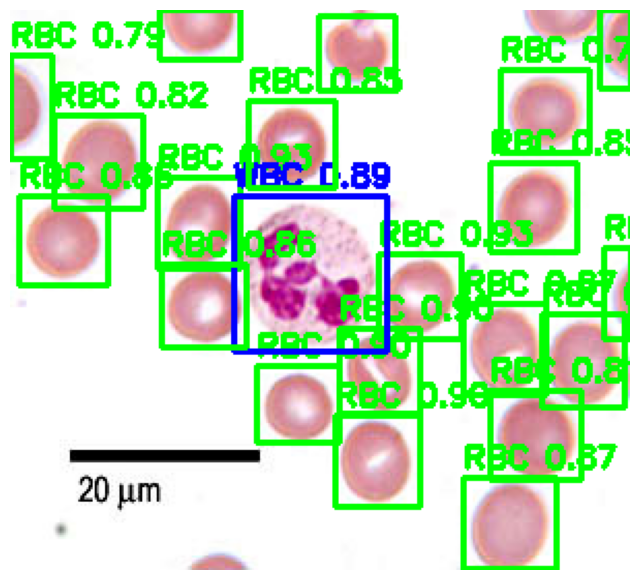

In [33]:
visualize_inference("test.jpg", best_model)


0: 512x640 (no detections), 17.5ms
Speed: 12.0ms preprocess, 17.5ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 640)


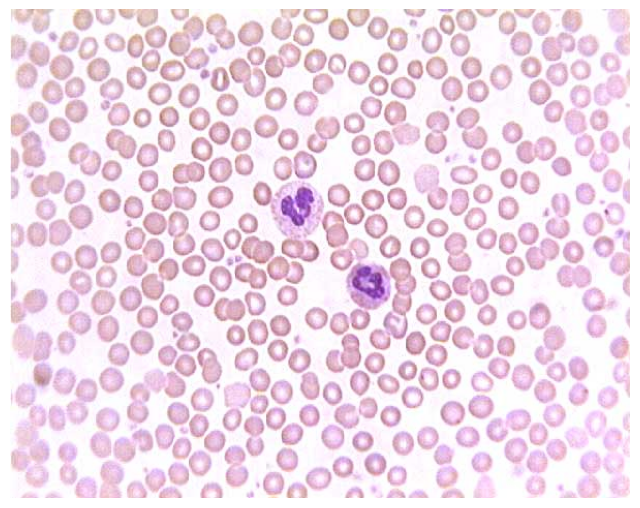

In [38]:
visualize_inference("test2.jpg", best_model)

SAHI (Trial)

In [35]:
from sahi import AutoDetectionModel

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path="runs/detect/11s_lr_augment/weights/best.pt",
    confidence_threshold=0.25,
    device="cuda"
)

In [36]:
from sahi.predict import get_sliced_prediction

result = get_sliced_prediction(
    "test2.jpg",
    detection_model,
    slice_height=256,
    slice_width=256,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2
)

Performing prediction on 9 slices.


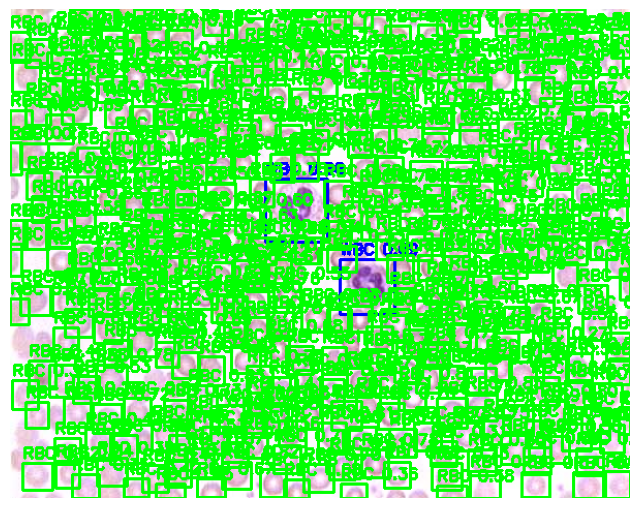

In [37]:
import cv2
import matplotlib.pyplot as plt

colors = {
    'WBC': (255, 0, 0),
    'RBC': (0, 255, 0),
    'Platelets': (0, 0, 255)
}

img = cv2.imread("test2.jpg")

for obj in result.object_prediction_list:
    bbox = obj.bbox
    x1, y1, x2, y2 = map(int, [bbox.minx, bbox.miny, bbox.maxx, bbox.maxy])
    
    label = obj.category.name
    score = obj.score.value

    color = colors.get(label, (255, 255, 255)) 

    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

    cv2.putText(
        img,
        f"{label} {score:.2f}",
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        2
    )

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()